In [1]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm

import matplotlib.cm as cm
import colormaps as cmaps
import matplotlib.colors as colors
from labellines import labelLines
from matplotlib.cm import brg, ScalarMappable
from matplotlib.colors import (
    LogNorm,
    TwoSlopeNorm,
    LinearSegmentedColormap,
    Normalize,
    ListedColormap,
)
from matplotlib.lines import Line2D

import jax
import jax.numpy as jnp
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

import yaml
from pathlib import Path

import EI.ei_unified as eu
import EI.ei_jax_2 as ej
import EI.ei_phonon as pb
from EI.ei_utils import gap_info
from fixed_baths import k_path, take_path, color_line, solve_state, plot_dispersion

from utils.logger import logger, tqdm_bar
from utils.plotting_utils import Plotter, plot_cmap, format_ax, add_legend, plot_cmap, plot_phase_diag, color_map


import importlib
pb = importlib.reload(pb)
ej = importlib.reload(ej)
jax.clear_caches()

/home/kzeleznikar/IJS-F1/.venv/lib/python3.13/site-packages/sacred/dependencies.py:11: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


In [2]:
from utils.cosmetics import apply_plt_style, SET1_LIST
apply_plt_style()

OUT = "/home/kzeleznikar/IJS-F1/Koda/EI_baths/"
from matplotlib_inline.backend_inline import set_matplotlib_formats
set_matplotlib_formats("png", dpi=300)

In [3]:
cfg_path = Path("/home/kzeleznikar/IJS-F1/Koda/EI_baths/config/config_test.yaml")
cfg_ph_path = Path("/home/kzeleznikar/IJS-F1/Koda/EI_baths/config/config_phonons.yaml")

with cfg_path.open("r") as f:
    cfg = yaml.safe_load(f)
with cfg_ph_path.open("r") as f:
    cfg_ph = yaml.safe_load(f)

md = cfg_ph["model"]
eq = cfg_ph["equilibrium"]
sc = cfg_ph["scan"]
op = cfg_ph["open_system"]
op_prod = cfg["open_system"]

nk = md["nk"]
bp = md["band"]["pars"]

bd = eu.tb_2d(nk["scan"], **bp)
bd_ref = eu.tb_2d(nk["reference"], **bp)

p = eu.MFPars(**md["mean_field"])

In [4]:
s0 = eu.solve_eq(bd_ref, p, **eq["initial"], **eq["solve"])

d0 = abs(s0.d)
m0 = s0.m
mu0 = s0.mu

# za normalizacijo
tc = eu.critical_temperature(bd_ref, p, **eq["critical"])

logger.info(f"Delta_0 = {d0}")
logger.info(f"m_0     = {m0}")
logger.info(f"mu0     = {mu0}")
logger.info(f"T_c     = {tc}")

kriticna temp bisekcija:   0%|          | 0/100 [00:00<?, ?it/s]

[21:18:13] [INFO    ] Delta_0 = 1.0000516844764111
[21:18:13] [INFO    ] m_0     = -0.6843383434372652
[21:18:13] [INFO    ] mu0     = 3.2003407445809757
[21:18:13] [INFO    ] T_c     = 0.5352354225531222


In [5]:
tg = sc["temperature"]

tn = np.linspace( tg["min_ratio"], tg["max_ratio"], tg["nt"])

t1a = tn * tc
t2a = tn * tc
nt = tg["nt"]

In [6]:
st = ej.mf_state(bd_ref, p, s0.d, s0.m)
t1n, t2n = 6.5, 0.2
t1, t2 = t1n * tc, t2n * tc

In [7]:
st.eah

Array([6.50554436, 6.48977376, 6.44271068, ..., 6.34932673, 6.42694008,
       6.47400316], dtype=float64)

In [8]:
bc = op["bath"]
fn = getattr(pb, bc["rate"])
pa = dict(bc["pars"])

tb = 0.75 * tc

bs = (
    fn(
        tb, bd.k, name="constant",
        **{
            **pa,
            "disp": "constant",
            "w0": 3.5,
            "ew": 0.15,
        },
    ),
    fn(
        tb, bd.k, name="acoustic",
        **{
            **pa,
            "disp": "acoustic",
        },
    ),
    fn(
        tb, bd.k, name="gapped",
        **{
            **pa,
            "disp": "gapped",
            "length": 10.0,
        },
    ),
)

bl = ("constant", "acoustic", "gapped")

In [9]:
st = ej.mf_state(
    bd, p,
    d=float(s0.d),
    m=float(s0.m),
)

kg = np.asarray(bd.k, dtype=float)
ip = int(np.argmin(np.linalg.norm(kg, axis=1)))

per = 2.0 * np.pi / bs[0].a0
qk = (kg - kg[ip] + 0.5 * per) % per - 0.5 * per

gm = []

for b in tqdm(bs, desc="Coupling matrices"):
    z = [
        np.asarray(
            jax.device_get(
                pb.g_mat(st, b, ik, ip, qk[ik])
            )
        )
        for ik in range(bd.size)
    ]
    gm.append(np.stack(z))

gm = np.stack(gm)

Coupling matrices:   0%|          | 0/3 [00:00<?, ?it/s]

In [10]:
gm.shape

(3, 400, 2, 2)

findfont: Failed to find font weight normal, now using 300.
/tmp/ipykernel_58738/1327166517.py:54: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
findfont: Failed to find font weight normal, now using 300.


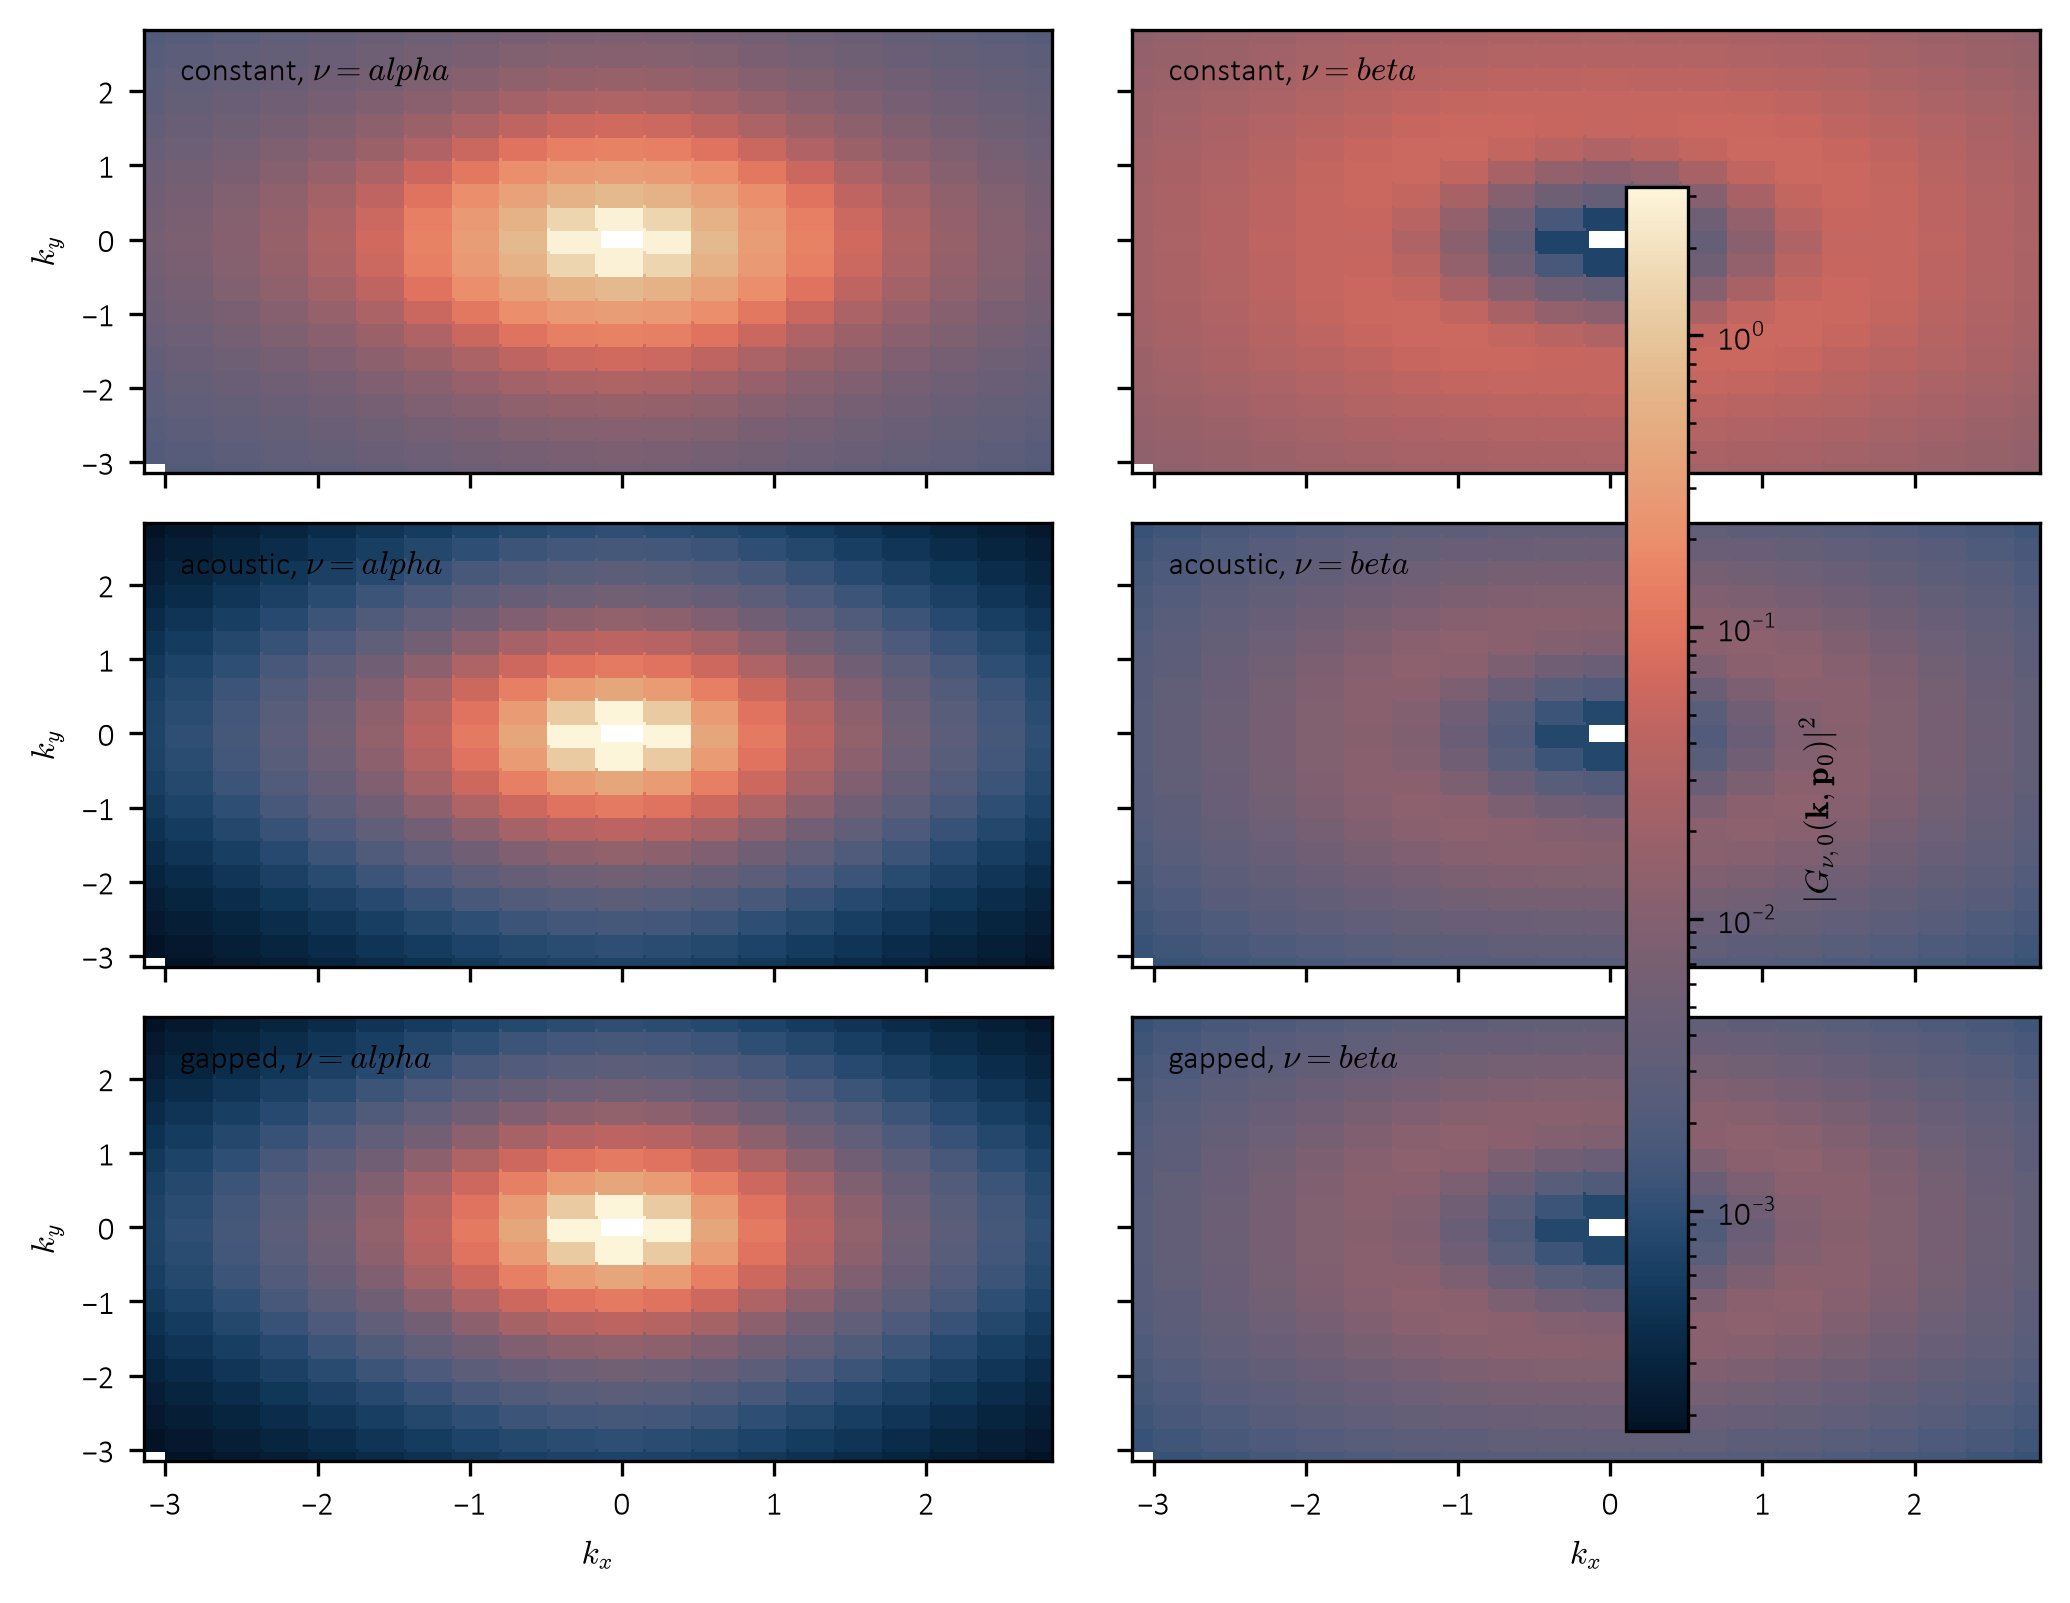

In [11]:
mu = 0

kx = kg[:, 0].reshape(bd.shape)
ky = kg[:, 1].reshape(bd.shape)
z = np.abs(gm[:, :, :, mu])**2

zp = z[z > 0.0]
vmax = float(np.max(zp))
vmin = max(float(np.min(zp)), 1.0e-8 * vmax)
norm = LogNorm(vmin=vmin, vmax=vmax)

h = 1.55
fig, ax = plt.subplots(
    3, 2,
    sharex=True,
    sharey=True,
    figsize=(2 * 3.47412, h * 3.47412),
)

for ib in range(3):
    for nu in range(2):
        zz = z[ib, :, nu].reshape(bd.shape)
        zz = np.ma.masked_less_equal(zz, 0.0)

        im = ax[ib, nu].pcolormesh(
            kx, ky, zz,
            shading="nearest",
            cmap=cmaps.lipari,
            norm=norm,
        )
        im.set_edgecolor("face")

        ax[ib, nu].set_xlim(kx.min(), kx.max())
        ax[ib, nu].set_ylim(ky.min(), ky.max())
        ax[ib, nu].text(
            0.04, 0.94,
            rf"{bl[ib]}, $\nu={['alpha', 'beta'][nu]}$",
            transform=ax[ib, nu].transAxes,
            va="top",
        )

    ax[ib, 0].set_ylabel(r"$k_y$")

for a in ax[-1]:
    a.set_xlabel(r"$k_x$")

cbar = plt.colorbar(im, ax=ax)
cbar.set_label(
    rf"$|G_{{\nu,{mu}}}(\mathbf{{k}},\mathbf{{p}}_0)|^2$",
    rotation=90,
    labelpad=5,
)

plt.tight_layout()
plt.show()

In [12]:
mu = 0
ewp = 0.02

kg = np.asarray(bd.k, dtype=float)
ek = np.asarray(st.e, dtype=float)

ip = int(np.argmin(np.linalg.norm(kg, axis=1)))

per = 2.0 * np.pi / bs[0].a0
qk = (kg - kg[ip] + 0.5 * per) % per - 0.5 * per
qm = np.linalg.norm(qk, axis=1)

kx = kg[:, 0].reshape(bd.shape)
ky = kg[:, 1].reshape(bd.shape)

def delta_e(x, ew):
    return ew / (np.pi * (x * x + ew * ew))

z = np.zeros((len(bs), 2, bd.size))

for ib, b in enumerate(tqdm(bs, desc="Bose-energy factors")):
    om = np.asarray(
        jax.device_get(
            pb.omega_q(jnp.asarray(qm), b)
        )
    )

    nq = np.zeros_like(om)
    mq = om > 1.0e-12

    if b.t > 0.0:
        x = np.clip(om[mq] / b.t, 0.0, 700.0)
        nq[mq] = 1.0 / np.expm1(x)

    for nu in range(2):
        de = ek[nu] - ek[mu, ip]

        z[ib, nu] = (
            nq * delta_e(de - om, ewp)
            + (1.0 + nq) * delta_e(de + om, ewp)
        )

        z[ib, nu] = np.where(qm <= b.qd, z[ib, nu], 0.0)

    if b.disp == "acoustic":
        z[ib, :, ~mq] = np.nan

Bose-energy factors:   0%|          | 0/3 [00:00<?, ?it/s]

/tmp/ipykernel_58738/384693871.py:52: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


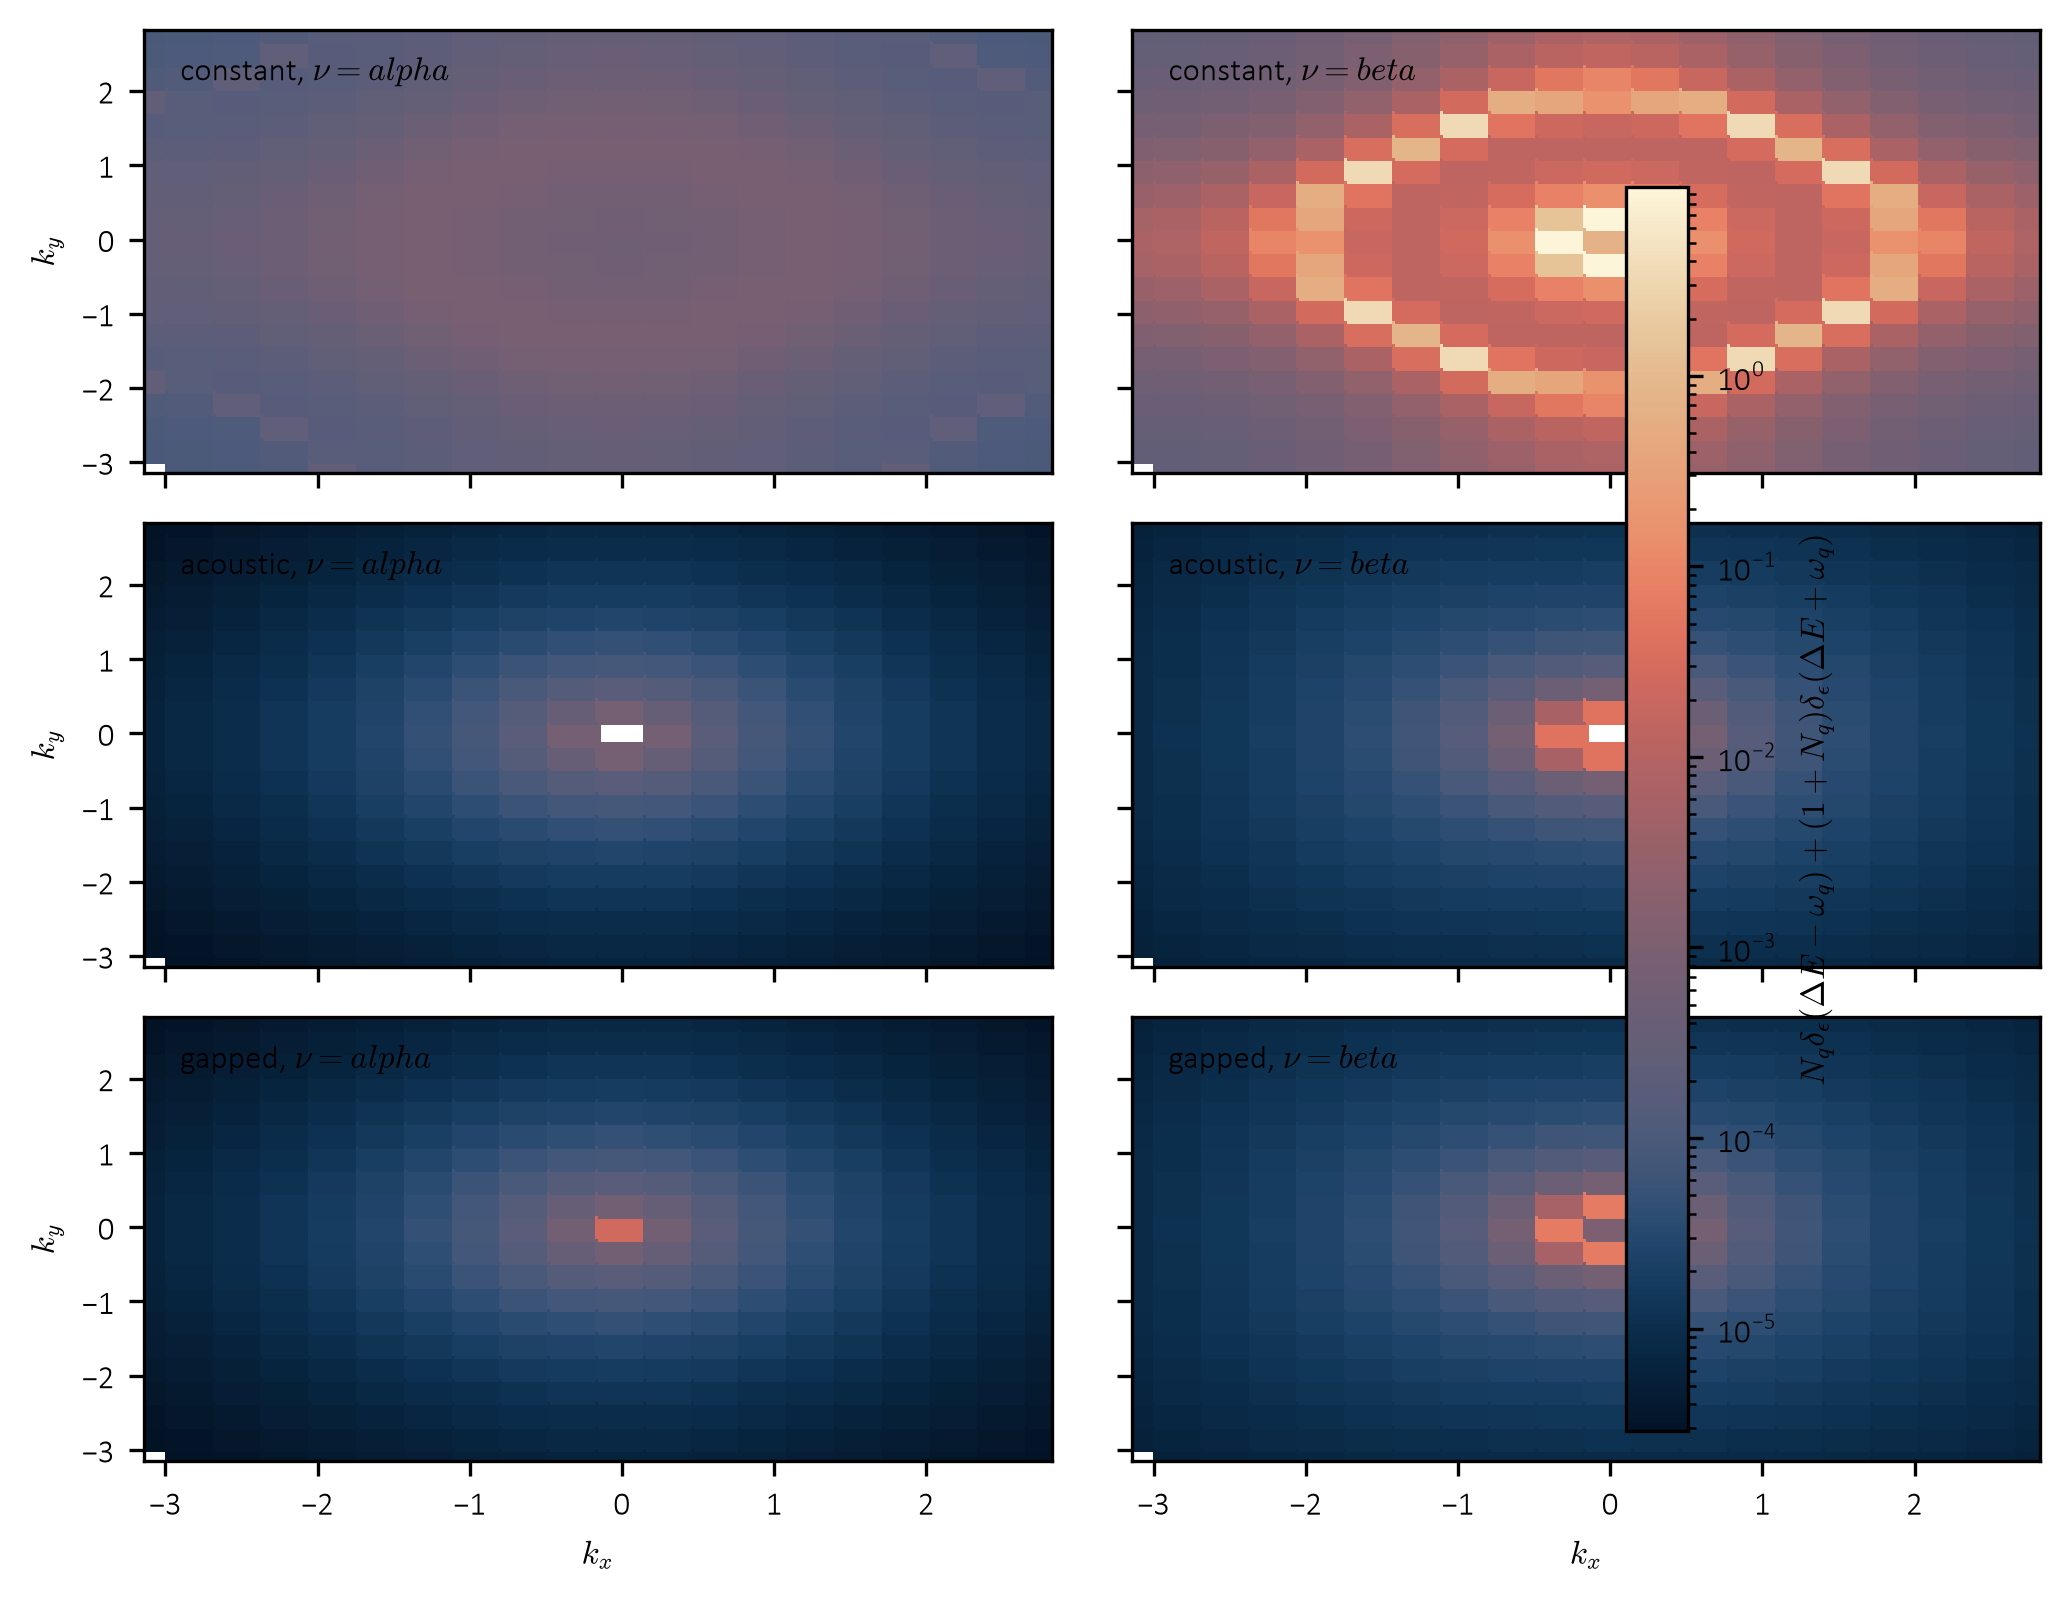

In [13]:
zp = z[np.isfinite(z) & (z > 0.0)]
vmax = float(np.max(zp))
vmin = max(float(np.min(zp)), 1.0e-8 * vmax)
norm = LogNorm(vmin=vmin, vmax=vmax)

h = 1.55
fig, ax = plt.subplots(
    3, 2,
    sharex=True,
    sharey=True,
    figsize=(2 * 3.47412, h * 3.47412),
)

for ib in range(3):
    for nu in range(2):
        zz = np.ma.masked_invalid(
            z[ib, nu].reshape(bd.shape)
        )
        zz = np.ma.masked_less_equal(zz, 0.0)

        im = ax[ib, nu].pcolormesh(
            kx, ky, zz,
            shading="nearest",
            cmap=cmaps.lipari,
            norm=norm,
        )
        im.set_edgecolor("face")

        ax[ib, nu].set_xlim(kx.min(), kx.max())
        ax[ib, nu].set_ylim(ky.min(), ky.max())

        ax[ib, nu].text(
            0.04, 0.94,
            rf"{bl[ib]}, $\nu={['alpha', 'beta'][nu]}$",
            transform=ax[ib, nu].transAxes,
            va="top",
        )

    ax[ib, 0].set_ylabel(r"$k_y$")

for a in ax[-1]:
    a.set_xlabel(r"$k_x$")

cbar = plt.colorbar(im, ax=ax)
cbar.set_label(
    r"$N_q\delta_\epsilon(\Delta E-\omega_q)"
    r"+(1+N_q)\delta_\epsilon(\Delta E+\omega_q)$",
    rotation=90,
    labelpad=5,
)

plt.tight_layout()
plt.show()

In [14]:
disp = "constant"
mu = 0

b = next(q for q in bs if q.disp == disp)

st = ej.mf_state(
    bd, p,
    d=float(s0.d),
    m=float(s0.m),
)

ij, x, xt = k_path(bd)

kg = np.asarray(bd.k, dtype=float)
ek = np.asarray(st.e, dtype=float)

ip = np.ravel_multi_index(
    tuple(ij[25]),
    bd.shape,
)

per = 2.0 * np.pi / b.a0
qk = (kg - kg[ip] + 0.5 * per) % per - 0.5 * per
qm = np.linalg.norm(qk, axis=1)

om = np.asarray(
    jax.device_get(
        pb.omega_q(jnp.asarray(qm), b)
    )
)

de = ek - ek[mu, ip]
# de=ek-md["mean_field"]["v"]/2
gm = []

for ik in tqdm(range(bd.size), desc="G matrix"):
    g = pb.g_mat(st, b, ik, ip, qk[ik])
    gm.append(np.asarray(jax.device_get(g)))

gm = np.stack(gm)
g2 = np.abs(gm[:, :, mu].T)**2

def delta_e(y, ew):
    return ew / (np.pi * (y * y + ew * ew))

nq = np.zeros_like(om)
mq = om > 1.0e-12

if b.t > 0.0:
    y = np.clip(om[mq] / b.t, 0.0, 700.0)
    nq[mq] = 1.0 / np.expm1(y)

bf = (
    nq[None, :] * delta_e(de - om[None, :], ewp)
    + (1.0 + nq[None, :])
    * delta_e(de + om[None, :], ewp)
)

bf[:, qm > b.qd] = 0.0

if b.disp == "acoustic":
    bf[:, ~mq] = np.nan


gr = np.asarray(
    jax.device_get(
        pb.source_rates(st, (b,), mu, ip)
    )
)
ep = take_path(de, ij, bd.shape)
wp = take_path(om, ij, bd.shape)
gp = take_path(g2, ij, bd.shape)
fp = take_path(bf, ij, bd.shape)
rp = take_path(gr, ij, bd.shape)

G matrix:   0%|          | 0/400 [00:00<?, ?it/s]

Phonon kernel table:   0%|          | 0/64 [00:00<?, ?it/s]

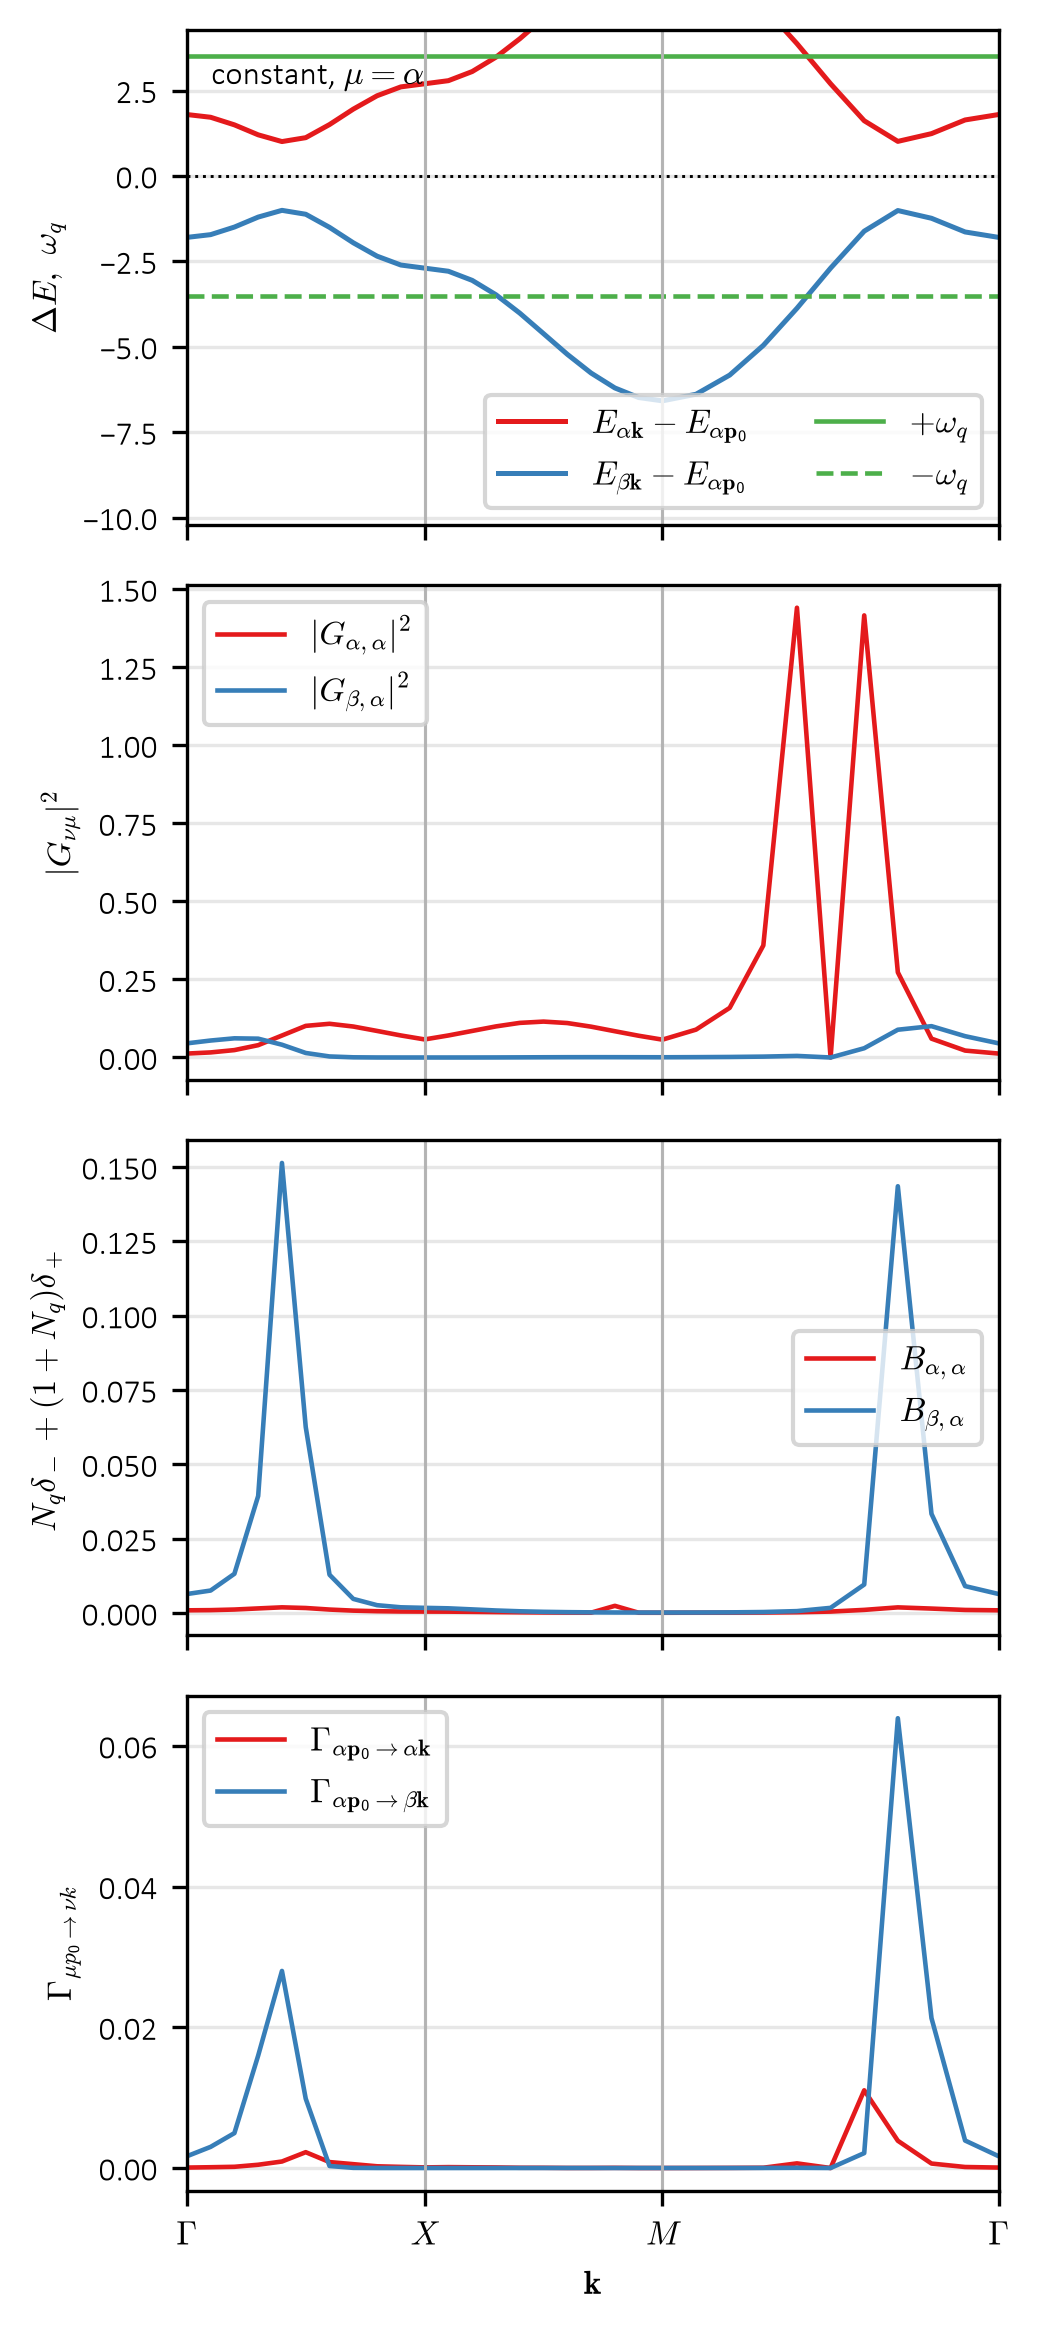

In [15]:
h = 2.25
fig, ax = plt.subplots(
    4, 1,
    sharex=True,
    figsize=(3.47412, h * 3.47412),
)

cl = (SET1_LIST[0], SET1_LIST[1])
lb = (r"\alpha", r"\beta")

for nu in range(2):
    ax[0].plot(
        x, take_path(ek, ij, bd.shape)[nu],
        # x, ep[nu],
        color=cl[nu],
        linewidth=1.2,
        label = rf"$E_{{{lb[nu]}\mathbf{{k}}}}-E_{{{lb[mu]}\mathbf{{p}}_0}}$",
    )

ax[0].plot(
    x, wp,
    color=SET1_LIST[2],
    linewidth=1.1,
    label=r"$+\omega_{q}$",
)
ax[0].plot(
    x, -wp,
    color=SET1_LIST[2],
    linestyle="--",
    linewidth=1.1,
    label=r"$-\omega_{q}$",
)
ax[0].axhline(0.0, color="black", linestyle=":", linewidth=0.7)
ax[0].set_ylabel(r"$\Delta E,\ \omega_q$")
ax[0].legend(ncol=2)
ax[0].set_ylim(1.1*min(ep[nu]), 1.1*max(ep[mu]))


for nu in range(2):
    # y = np.where(gp[nu] > 0.0, gp[nu], np.nan)
    y=gp[nu]
    ax[1].plot(
        x, y,
        color=cl[nu],
        linewidth=1.1,
        label = rf"$|G_{{{lb[nu]},{lb[mu]}}}|^2$",
    )

ax[1].set_ylabel(r"$|G_{\nu\mu}|^2$")
ax[1].legend()

for nu in range(2):
    # y = np.where(fp[nu] > 0.0, fp[nu], np.nan)
    y=fp[nu]
    ax[2].plot(
        x, y,
        color=cl[nu],
        linewidth=1.1,
        label = rf"$B_{{{lb[nu]},{lb[mu]}}}$",
    )

ax[2].set_ylabel(
    r"$N_q\delta_-+(1+N_q)\delta_+$"
)
ax[2].legend()

for nu in range(2):
    # y = np.where(rp[nu] > 0.0, rp[nu], np.nan)
    y=rp[nu]
    ax[3].plot(
        x, y,
        color=cl[nu],
        linewidth=1.1,
        label = rf"$\Gamma_{{{lb[mu]}\mathbf{{p}}_0\rightarrow {lb[nu]}\mathbf{{k}}}}$",
    )

ax[3].set_ylabel(r"$\Gamma_{\mu p_0\rightarrow\nu k}$")
ax[3].set_xlabel(r"$\mathbf{k}$")
ax[3].legend()

for a in ax:
    a.set_xlim(x[0], x[-1])
    a.grid(alpha=0.3)

    for xv in xt[1:-1]:
        a.axvline(
            xv,
            color="0.7",
            linewidth=0.7,
        )

ax[-1].set_xticks(xt)
ax[-1].set_xticklabels(
    [r"$\Gamma$", r"$X$", r"$M$", r"$\Gamma$"]
)

ax[0].text(
    0.03, 0.94,
    rf"{disp}, $\mu={lb[mu]}$",
    transform=ax[0].transAxes,
    va="top",
)

plt.tight_layout()
plt.show()

In [22]:
r1, r2 = 0.7, 0.7
t1, t2 = r1 * tc, r2 * tc
eta_a = np.array([0.025])

se = eu.solve_eq(
    bd, p, t=t2, d=d0, m=s0.m,
    **{**eq["solve"], "prog": False},
)

w = np.asarray(bd.w, dtype=float)

ni = np.full_like(se.n, float(p.n) / (2.0 * np.sum(w)))
di, mi = 0.8, -0.6

ns = int(op["solve"]["chk"]) // 10
nstep = int(op["solve"]["nmax"]) 

mix = (0.5, 0.5, 0.5)
tol = 1.0e-6

out = []
fin = []

for eta in tqdm(eta_a, desc="Energy widths"):
    bp = {
        **bc["pars"],
        "eta": float(eta),
        "disp": "constant",
        "w0": 3.5,
        "ew": 0.3,
    }

    bs = (
        fn(t1, bd.k, name="bath_1", **bp),
        fn(t2, bd.k, name="bath_2", **bp),
    )

    so = ej.solve_fixed(
        bd, p, ni.copy(), bs,
        d=di, m=mi,
        mix=mix,
        tol=tol,
        nmax=nstep,
        chk=ns,
        prog=True,
    )

    hq = so.hist

    si = ej.mf_state(bd, p, d=di, m=mi)
    ti = ej.targets(bd, p, si, ni)
    g0 = float(ti.d) / di
    a0 = float(np.sum(w * ni[0]))

    z = {
        "it": np.r_[0, hq["it"]],
        "d": np.r_[di, hq["d"]],
        "m": np.r_[mi, hq["m"]],
        "na": np.r_[a0, hq["na"]],
        "gn": np.r_[g0, hq["gn"]],
        "err": np.r_[np.nan, hq["err"]],
        "cur": np.r_[np.nan, hq["cur"]],
    }

    out.append({q: np.asarray(v) for q, v in z.items()})
    fin.append({
        "n": so.n.copy(),
        "d": float(so.d),
        "m": float(so.m),
        "err": float(so.err),
        "ok": bool(so.ok),
    })

Energy widths:   0%|          | 0/1 [00:00<?, ?it/s]

Fixed EI JAX:   0%|          | 0/2000 [00:00<?, ?it/s]

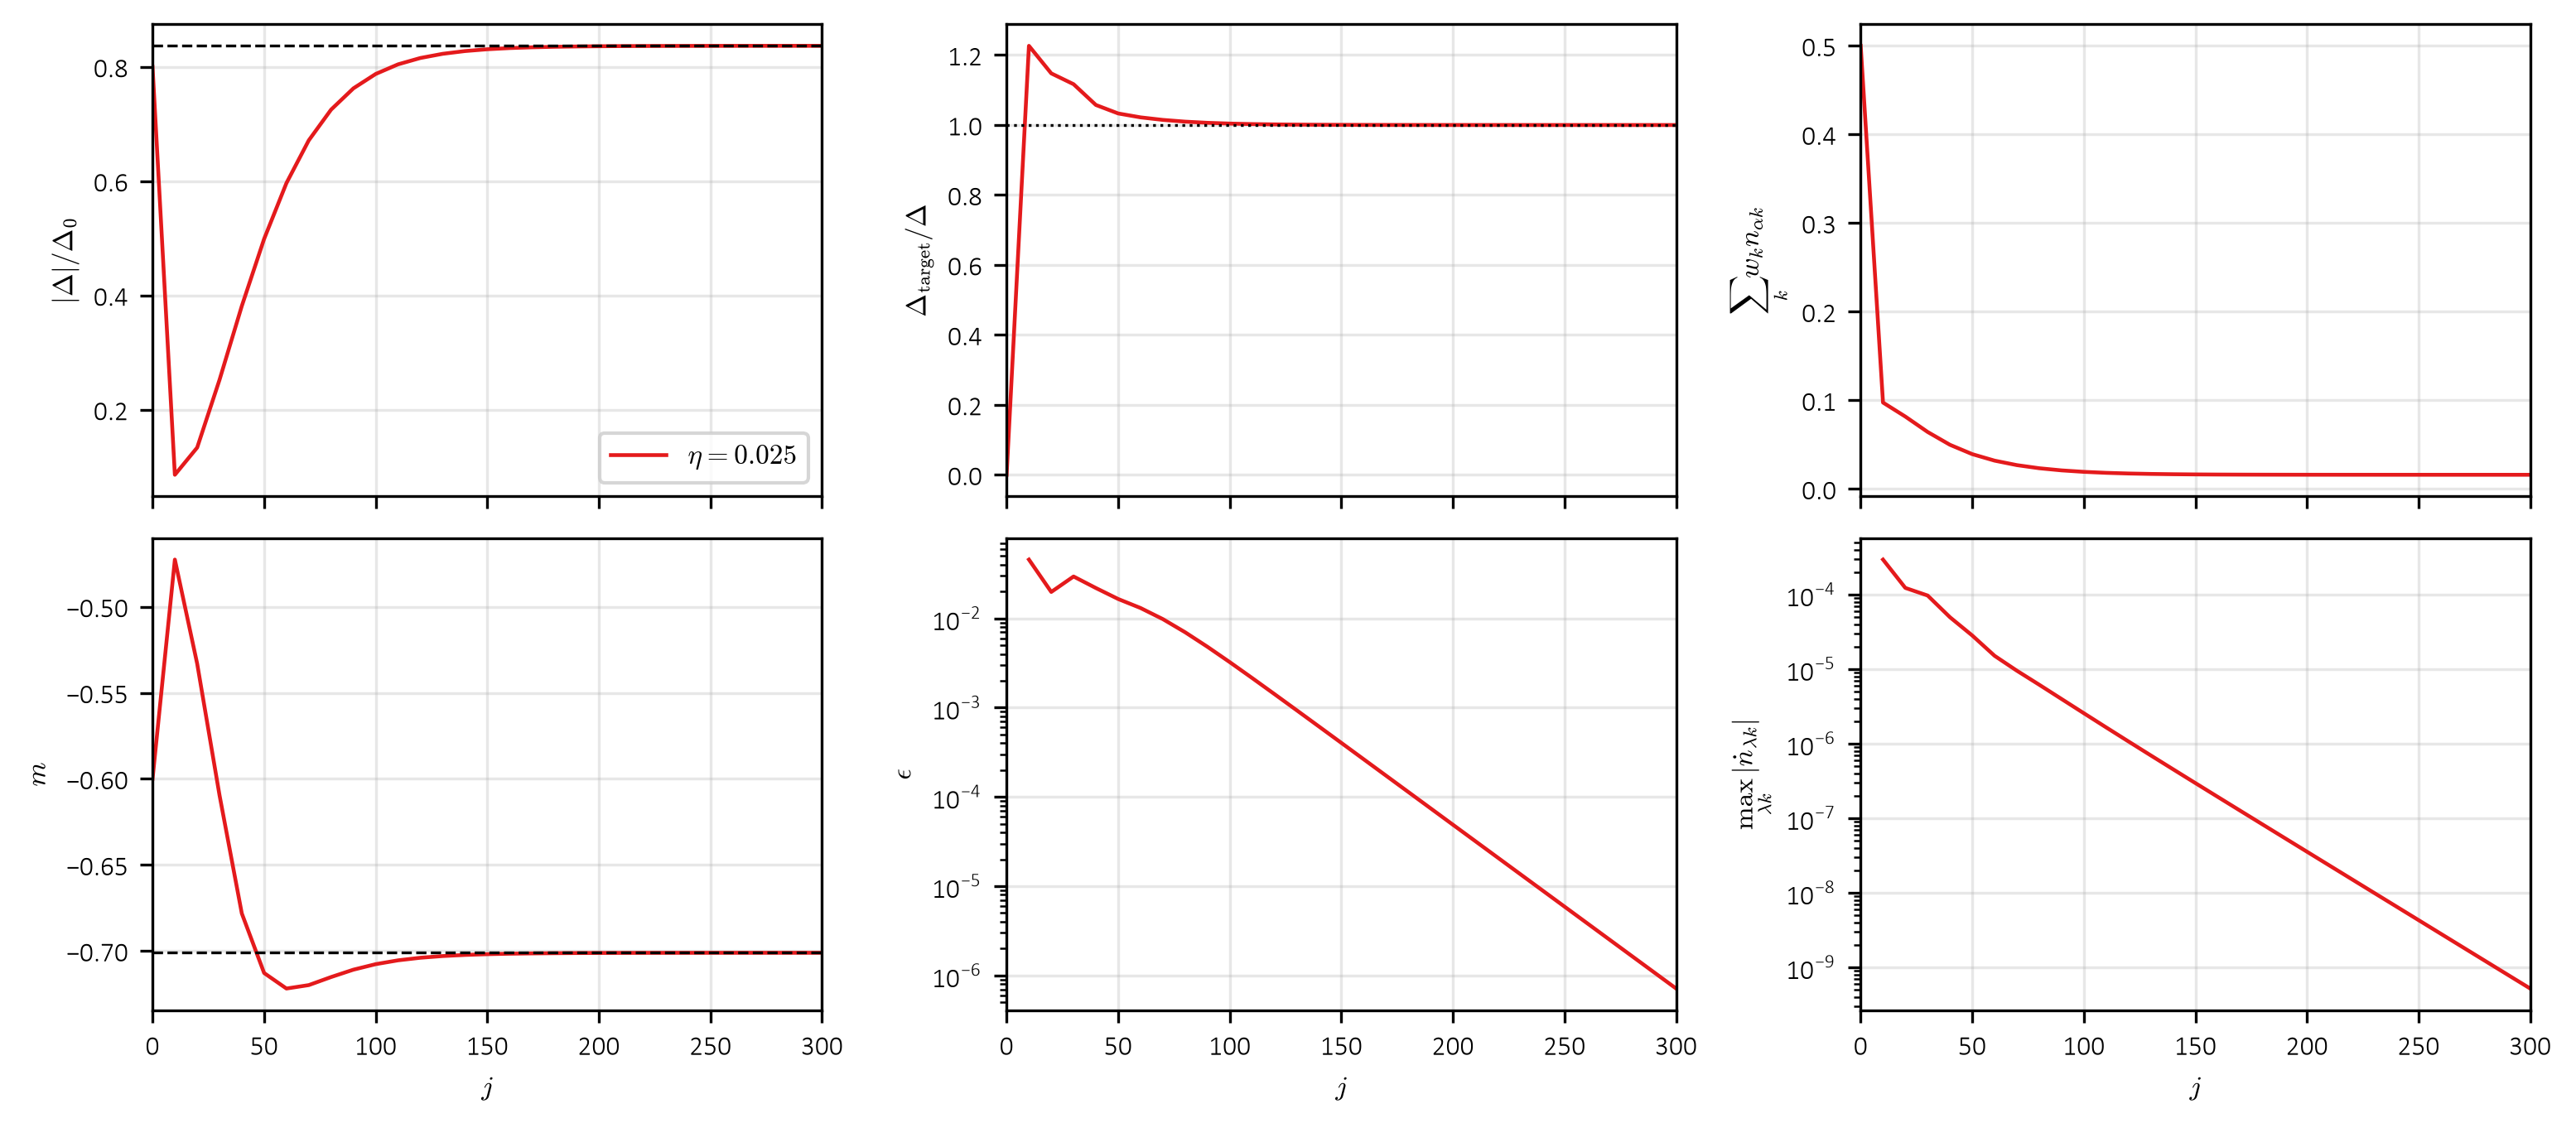

In [23]:
h = 1.45
fig, ax = plt.subplots(
    2, 3, sharex=True,
    figsize=(3 * 3.47412, h * 3.47412),
)

for i, eta in enumerate(eta_a):
    c = SET1_LIST[i]
    z = out[i]
    lb = rf"$\eta={eta:g}$"

    ax[0, 0].plot(
        z["it"], np.abs(z["d"]) / d0,
        color=c, linestyle="-", linewidth=1.1, label=lb,
    )
    ax[0, 1].plot(
        z["it"], z["gn"],
        color=c, linestyle="-", linewidth=1.1,
    )
    ax[0, 2].plot(
        z["it"], z["na"],
        color=c, linestyle="-", linewidth=1.1,
    )
    ax[1, 0].plot(
        z["it"], z["m"],
        color=c, linestyle="-", linewidth=1.1,
    )
    ax[1, 1].semilogy(
        z["it"][1:], z["err"][1:],
        color=c, linestyle="-", linewidth=1.1,
    )
    ax[1, 2].semilogy(
        z["it"][1:], z["cur"][1:],
        color=c, linestyle="-", linewidth=1.1,
    )

ax[0, 1].axhline(
    1.0, color="black",
    linestyle=":", linewidth=0.8,
)

ax[0, 0].axhline(
    se.d /d0, color="black",
    linestyle="--", linewidth=0.8,
)

ax[1, 0].axhline(
    se.m, color="black",
    linestyle="--", linewidth=0.8,
)
ax[0, 0].set_ylabel(r"$|\Delta|/\Delta_0$")
ax[0, 1].set_ylabel(r"$\Delta_{\mathrm{target}}/\Delta$")
ax[0, 2].set_ylabel(r"$\sum_k w_k n_{\alpha k}$")
ax[1, 0].set_ylabel(r"$m$")
ax[1, 1].set_ylabel(r"$\epsilon$")
ax[1, 2].set_ylabel(r"$\max_{\lambda k}|\dot n_{\lambda k}|$")

for a in ax.ravel():
    a.set_xlim(z["it"][0], z["it"][-1])
    a.grid(alpha=0.3)

for a in ax[1]:
    a.set_xlabel(r"$j$")

hd, lb = ax[0, 0].get_legend_handles_labels()
ax[0,0].legend()

plt.tight_layout(rect=(0, 0, 1, 0.91))
plt.show()

In [18]:
tn = np.asarray(tn, dtype=float)
t1a = tn * tc
t2a = tn * tc
nt = tn.size

bc = op["bath"]
bp = {**bc["pars"], "eta": float(eta), "disp": "constant", "w0": 3.5, "ew": 0.30,}

fp = {
    "mix": (0.5, 0.5, 0.5),
    "tol": 1.0e-6,
    "nmax": 20000,
    "chk": 100,
    "prog": False,
}

da = np.full((nt, nt), np.nan)
ma = np.full((nt, nt), np.nan)
er = np.full((nt, nt), np.nan)
it = np.zeros((nt, nt), dtype=int)
ok = np.zeros((nt, nt), dtype=bool)

de = float(s0.d)
me = float(s0.m)
ds = 1.0e-3 * max(abs(d0), 1.0)

total_steps = nt * (nt + 1) // 2

with tqdm(total=total_steps, desc="Map Progress") as pbar:
    for j in range(nt):
        t2 = float(t2a[j])
        se = eu.solve_eq(
            bd, p, t=t2,
            d=max(abs(de), 1.0e-8),
            m=me,
            **{**eq["solve"], "prog": False},
        )

        n = se.n.copy()
        d = float(se.d)
        m = float(se.m)
        # n = np.ones_like(se.n.copy())*0.5
        # d = 0.8
        # m = -0.6

        for i in range(j, nt):
            t1 = float(t1a[i])
            bs = (
                fn(t1, bd.k, name="bath_1", **bp),
                fn(t2, bd.k, name="bath_2", **bp),
            )

            so = ej.solve_fixed(
                bd, p, n, bs,
                d=d,
                m=m,
                **fp,
            )

            da[j, i] = da[i, j] = abs(so.d)
            ma[j, i] = ma[i, j] = so.m
            er[j, i] = er[i, j] = so.err
            it[j, i] = it[i, j] = so.it
            ok[j, i] = ok[i, j] = so.ok

            n = so.n.copy()
            d = max(abs(float(so.d)), ds)
            m = float(so.m)

            pbar.update(1)  

        de = float(se.d)
        me = float(se.m)

print(f"Converged: {np.count_nonzero(ok)} / {ok.size}")
print(f"Nonconverged: {np.count_nonzero(~ok)}")
print(f"Maximum residual: {np.nanmax(er):.3e}")

Map Progress:   0%|          | 0/120 [00:00<?, ?it/s]

Converged: 168 / 225
Nonconverged: 57
Maximum residual: 2.559e-02


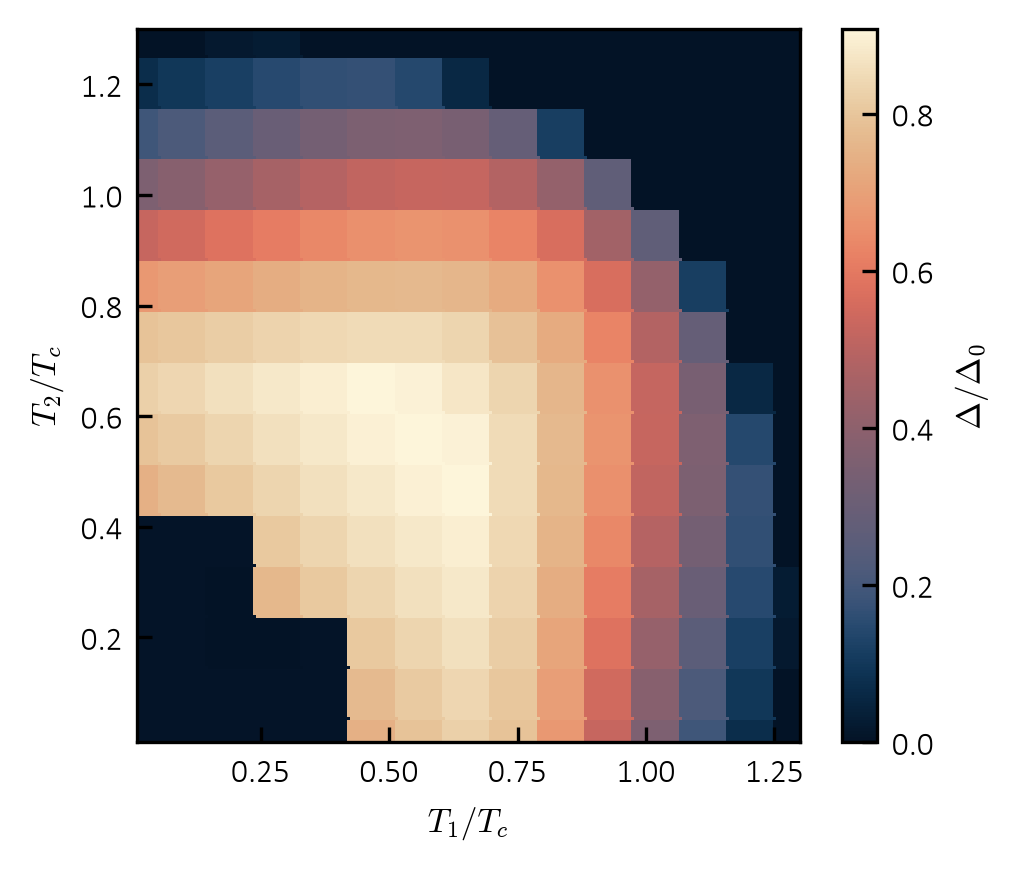

(<Figure size 347.412x295.3 with 2 Axes>,
 <Axes: xlabel='$T_1/T_c$', ylabel='$T_2/T_c$'>)

In [19]:
plot_phase_diag(da, d0, tn)